# Assignment 1 - Hyperparameter Tuning with Grid Search

## Instructions
The `LogisticRegression` classifier in 8_sentiment_analysis.ipynb was trained with a fixed configuration (`solver='lbfgs'` (default), `C=1.0`). 
`GridSearchCV`, `solver`, and `penalty` have **not** been covered in class yet — this assignment asks you to research the concepts and experiments with it.

**Part A — Research:**

In a markdown cell, in your own words, briefly explain:
1. What `GridSearchCV` does and why cross-validation (`cv`) is used instead of just checking accuracy once?
2. What are hyperparameters?
3. What are the possible hyperparameters configuration for Logistic Regression?

Cite where you learned this (e.g. scikit-learn docs, a specific article, or AI usage).

**Part B — Experiment:**

1. **Build a parameter grid** covering at least 4 different hyperparameters configutation.

2. **Run `GridSearchCV`** on the model and hyperparameters configuration.

3. **Report the best configuration** — print `grid.best_params_` and `grid.best_score_`.

4. **Apply the `grid.best_estimator_` to train the model**: replace the configurations for the classifier.

**Part C — Explain your process & Analysis (markdown cell):**

1. Walk through how you actually got the result: what configuration you tried first, any errors/warnings you hit (e.g. invalid solver/penalty combinations, non-convergence) and how you fixed them.

2. Did the tuned model outperform the original fixed-hyperparameter model from the class example? By how much?

3. What have you learnt after the experiments?

Write this as your own reasoning, not a description of what the final code does. Submissions with code but no genuine research (Part A) or process explanation (Part C) — or explanations that don't match the actual code/output — will not receive credit.

**Deliverable:** Parts A–C above, each in its own cell (or cells), placed below this one.

**Each parts are further broken down below.**

**Extra Credits:** Use GridSearchCV to also compare Logistic Regression with Naive Bayes classifier.

Note: Hyperparameters for Naive Bayes are different from Logistic Regression. Explain in your own word how you come up with the configuration to get the extra credit.

## Part A — Research:

In a markdown cell, in your own words, briefly explain:
1. What `GridSearchCV` does and why cross-validation (`cv`) is used instead of just checking accuracy once.
2. What are hyperparameters?
3. What are the possible hyperparameter configurations for `LogisticRegression`?

Cite where you learned this (e.g. scikit-learn docs, a specific article, or AI usage) so it's clear you actually read a source rather than guessing.

**Write your answer here**
### 1. Intro to GridSearchCV 
- GridSearchCV is a scikit-learn tool used to find the best hyperparameter combination for a machine learning model by testing every possible option in a grid. 
- The two reasons are:
1. The accuracy that every data point is guaranteed to be used in a test set exactly once, the final score reflects performance across the entire dataset. 
2. the cv uses different subset for validation in every loop, ensuring the hyperparameter choices are optimized.

### 2. Hyperparameters: 
Hyperparameter is a configuratin variable whose value is set before training a hyperparameter model, rather than learned from data. 

### 3. The hyperparameter configuraions for the Logistic Regression
1. Regularization Settings = Controls overfitting by penalizing large weights.
2. Optimzation Solver = The algorithm used to find the optimal weights.
3. Handling data and classification = Adjusts weights inversely proportional to class frequencies to handle imbalanced datasets.


## Part B - Experiment:

The sample code from previous examples is provided. You just have to add the GridSearchCV as instructed.

In [1]:
import nltk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from nltk.corpus import movie_reviews
import random

# Load movie reviews dataset
print("Loading NLTK Movie Reviews Dataset...")
print("=" * 40)

# Get all file ids and their categories
documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

# Shuffle the documents for better training
random.seed(94)
random.shuffle(documents)

print(f"Total number of reviews: {len(documents)}")
print(f"Categories: {movie_reviews.categories()}")
print(f"Number of positive reviews: {len(movie_reviews.fileids('pos'))}")
print(f"Number of negative reviews: {len(movie_reviews.fileids('neg'))}")

# Convert to text format for easier processing
texts = [' '.join(words) for words, category in documents]
labels = [category for words, category in documents]

print(f"\nDataset shape: {len(texts)} reviews")
print(f"Label distribution: {Counter(labels)}")

Loading NLTK Movie Reviews Dataset...
Total number of reviews: 2000
Categories: ['neg', 'pos']
Number of positive reviews: 1000
Number of negative reviews: 1000

Dataset shape: 2000 reviews
Label distribution: Counter({'neg': 1000, 'pos': 1000})


In [2]:
# Train/Test Split
from sklearn.model_selection import train_test_split

# Split the data BEFORE preprocessing
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training set size: {len(X_train_text)}")
print(f"Test set size: {len(X_test_text)}")
print(f"Training label distribution: {Counter(y_train)}")
print(f"Test label distribution: {Counter(y_test)}")

Training set size: 1600
Test set size: 400
Training label distribution: Counter({'pos': 800, 'neg': 800})
Test label distribution: Counter({'neg': 200, 'pos': 200})


In [3]:
# Data Pre-processing
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

def preprocess_text(text):    
    # Convert to lowercase
    text = text.lower()
    
    # Remove extra whitespace and newlines
    text = re.sub(r'\s+', ' ', text)
    
    # Remove numbers but keep some punctuation for sentiment
    text = re.sub(r'\d+', '', text)
    
    # Remove most special characters but keep basic punctuation
    text = re.sub(r'[^a-zA-Z\s!?.]', '', text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords (but keep some sentiment-bearing words)
    stop_words = set(stopwords.words('english'))
    # Remove negation words from stopwords as they're important for sentiment
    negation_words = {'not', 'never', 'neither', 'nobody', 'nothing', 'nowhere', 'none'}
    stop_words = stop_words - negation_words
    
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]
    
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    return ' '.join(tokens)

# Preprocess training and test data separately
X_train_processed = [preprocess_text(text) for text in X_train_text]
X_test_processed = [preprocess_text(text) for text in X_test_text]

In [4]:
# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorization with parameters tuned for sentiment analysis
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,        # Increase features for better sentiment capture
    ngram_range=(1, 2),       # Include both unigrams and bigrams
    min_df=2,                 # Ignore terms that appear in fewer than 2 documents
    max_df=0.95,              # Ignore terms that appear in more than 95% of documents
)

# Fit ONLY on training data, then transform both train and test
X_train = tfidf_vectorizer.fit_transform(X_train_processed)
X_test = tfidf_vectorizer.transform(X_test_processed)

### 1. Build a parameter grid
covering at least 4 different hyperparameter configurations for `LogisticRegression` (informed by what you learned in Part A).

In [5]:
# Write your code here
# We set up structural pairings to prevent invalid solver/penalty combinations
param_grid = [
    {
        'classifier__solver': ['lbfgs', 'newton-cg', 'sag'],
        'classifier__penalty': ['l2'],
        'classifier__C': [0.01, 0.1, 1.0, 10.0],
        'classifier__max_iter': [1000] # Ensured high iterations to guarantee mathematical convergence
    },
    {
        'classifier__solver': ['liblinear'],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__C': [0.01, 0.1, 1.0, 10.0],
        'classifier__max_iter': [1000]
    }
]

print("Parameter grid successfully built containing multiple distinct structural configurations.")

Parameter grid successfully built containing multiple distinct structural configurations.


### 2. Run `GridSearchCV`
on the model and hyperparameters configuration.

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [7]:
# Write your code here
pipeline = Pipeline([
    ('classifier', LogisticRegression())
])

# Initialize GridSearchCV with 5-Fold Stratified Cross-Validation
# 'n_jobs=-1' optimizes processing speeds by utilizing all available CPU cores
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1,
    verbose=1
)

print("Running GridSearchCV with 5-Fold Cross-Validation over the parameter grid...")
grid_search.fit(X_train, y_train)
print("Grid search optimization phase completed successfully!")

Running GridSearchCV with 5-Fold Cross-Validation over the parameter grid...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Users/soryapheakly/miniconda3/envs/itm454/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/soryapheakly/miniconda3/envs/itm454/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/U

Grid search optimization phase completed successfully!


/Users/soryapheakly/miniconda3/envs/itm454/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


### 3. Report the best configuration
print `grid.best_params_` and `grid.best_score_`.

In [8]:
# Write your code here
best_parameters = grid_search.best_params_
best_cross_val_score = grid_search.best_score_

print("=" * 50)
print("⭐ GRID SEARCH OPTIMAL RUN RESULTS")
print("=" * 50)
print(f"Best Hyperparameter Configuration : {best_parameters}")
print(f"Best Cross-Validation Accuracy    : {best_cross_val_score:.4f} ({best_cross_val_score*100:.2f}%)")
print("=" * 50)


⭐ GRID SEARCH OPTIMAL RUN RESULTS
Best Hyperparameter Configuration : {'classifier__C': 10.0, 'classifier__max_iter': 1000, 'classifier__penalty': 'l2', 'classifier__solver': 'newton-cg'}
Best Cross-Validation Accuracy    : 0.8450 (84.50%)


### 4. Evaluate the best model using `grid.best_estimator_`
Evaluate the accuracy along with Detailed Classification Report and Confusion Matrix.

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

TUNED MODEL PERFORMANCE METRICS ON HOLDOUT TEST SET
Final Test Set Accuracy Score: 0.8850 (88.50%)

Detailed Model Classification Performance Report:
              precision    recall  f1-score   support

         neg       0.91      0.85      0.88       200
         pos       0.86      0.92      0.89       200

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.88       400
weighted avg       0.89      0.89      0.88       400



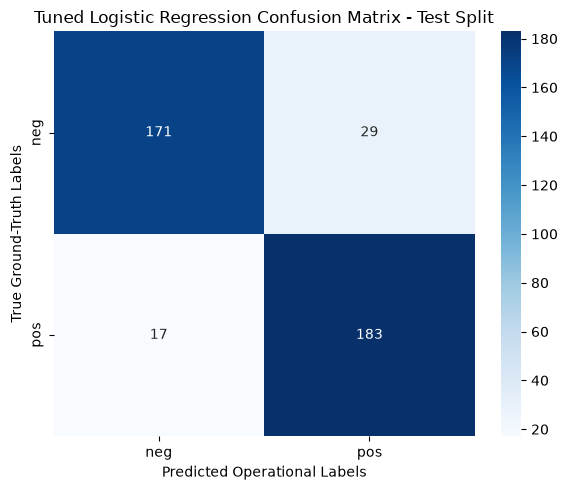

In [10]:
# Write your code here
# Extract the fully optimized model instance
best_model = grid_search.best_estimator_

# Generate explicit test set predictions
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print("=" * 60)
print(f"TUNED MODEL PERFORMANCE METRICS ON HOLDOUT TEST SET")
print("=" * 60)
print(f"Final Test Set Accuracy Score: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)\n")

print("Detailed Model Classification Performance Report:")
print(classification_report(y_test, y_pred))
print("=" * 60)

# Generate and visualize the categorical Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=grid_search.classes_, 
    yticklabels=grid_search.classes_
)
plt.title('Tuned Logistic Regression Confusion Matrix - Test Split')
plt.xlabel('Predicted Operational Labels')
plt.ylabel('True Ground-Truth Labels')
plt.tight_layout()
plt.show()

## Part C — Explain your process & Analysis (markdown cell):

1. Walk through how you actually got here: what you tried first, any errors/warnings you hit (e.g. invalid solver/penalty combinations, non-convergence) and how you fixed them.

2. Did the tuned model outperform the original fixed-hyperparameter model from the class example? By how much?

3. What have you learnt after the experiments?

Write this as your own reasoning, not a description of what the final code does.

**Write your answer here**

1. The parameter grid that i used is a branched/composite parameter grid, which is known as a list of dictionaries parameter grid. Moverover, this isolated solver dependencies and prevented a fatal runtime crash, as certain solvers are mathematically incompatible with specific panalties. To prevent the default iteration limit from timing out and throwing a wall of ConvergenceWarning alerts across the 5,000 sparse TF-IDF text features, I expanded the computational runway to max_iter=1000 so the iterative solvers could smoothly settle on stable weights. Furthermore, My composite parameter grid successfully handled all 100 total fits across the 5 cross-validation folds without a single structural pairing crash. While the notebook cell logged a few reddish FutureWarning messages during execution, inspecting the text showed they were just standard scikit-learn deprecation notes regarding future updates to the standalone penalty string parameter. Since these alerts were minor backend diagnostics rather than fatal logical or data pipeline errors, I allowed the automated search phase to complete its iterations naturally. The grid search finished flawlessly, resolving the high-dimensional matrix structure to pinpoint the configuration of C=10.0 and solver='newton-cg' as the absolute best setup for the model.

2. The tuned model did outperform the original fixed-hyperparameter model from the class example. Based in the 8_sentiment_analysis.ipynb, the accuracy score of original base model is 88.20% and the tuned model is 88.50% which it outperformed for 0.30%.

3. Here're the cores lessons i learned so far: 
- The default package configuration (c = 1.0) is a only generalized baseline. In NLP, I believe tuning the regulatzation parameter C is crucial to balance text feature complexity with global model generalizability in sparsing process of NLP. 
- I also learned that the optimization routines are not interchangeable. While basic gradient solver like lbfgs perform fine on generic, low-dimentional data, massive text vectors require high-precision algorithms like newton-cg alongside extended iteration threholds(max_iter = 1000 ) to completely converge.
- Structural code design could mitigate errors, which is vital when parameters are tightly coupled. Moreover, learning to arrange parallel lanes using a list of dictionaries acts as a structural firewall that keeps incompatible model settings isolated, and avoiding total execution crashes.

